# Spatial correlations in vote statistics: a diffusive field model for decision-making

Notebook servant au calcul des correlations spatiales

In [6]:
collab = False
save = True
type = 'T1'
election_type = 'pres'
years_to_exclude = []

## Imports and data loading

### Imports

In [7]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import joblib
import json
from shapely.geometry import shape
!pip install polars
import polars as pl
import warnings

In [8]:
if collab:
    from google.colab import drive
    drive.mount('/content/drive')

### Load data

In [9]:
def load_parquet_into_df(file_path, verbose = False):
    """Loads a Parquet file into a Pandas DataFrame."""
    try:
        df = pd.read_parquet(file_path)
        if verbose:
            print(f"Data loaded successfully from {file_path}")
        return df
    except Exception as e:
        print(f"Error loading file: {e}")
        return None

def load_all_data(directory):
    """Opens every parquet file in the given directory exploring all subdirectories."""
    #Directory containing the election files
    dfs_by_file = {}

    # Recursively explore subfolders and load each CSV file
    for dirpath, dirnames, filenames in os.walk(directory):
        for filename in filenames:
            if filename.endswith(".parquet"):
                filepath = os.path.join(dirpath, filename)

                # Load the data
                data = load_parquet_into_df(filepath)

                # Store the resulting DataFrame in the dictionary with the relative path as key
                relative_path = os.path.relpath(filepath, directory)
                dfs_by_file[relative_path] = data

    print('Data successfully loaded onto the Notebook')
    return dfs_by_file

In [14]:
if collab:
    directory = "/content/drive/My Drive/Projet_recherche_election"
else:
    directory = "../../data/raw/elections/"

dfs_by_file = load_all_data(directory)

Data successfully loaded onto the Notebook


# Distance correlations C_tau(r)

### Logit turnout rate

We consider a binary threshold $\rho = \dfrac{N-}{N+}$.

We consider the turnout rate $\pi$, it is given in the dataframe by the colmun ppar.

We consider a logarithmic turnout rate tau (for participation) and pho (for winning vote).

In order to avoid extreme cases we modify by 0.5 voice when $\pi = 0$ or $1$.

In [15]:
def add_logarithm_turnout_rates(dfs_by_file):
    """
    This function processes a dictionary of DataFrames, computes the 'tau' values
    for the turnout rate at the first round of each election loaded onto the notebook.
    """
    # Create a dictionary to store selected columns with valid tau
    selected_columns_df = {}

    for key, df in tqdm(dfs_by_file.items(), desc="Processing elections"):
        p = np.where(df['inscrits'] == 0.0, -1.0, df['votants'] / df['inscrits'])

        with np.errstate(divide='ignore', invalid='ignore'):
            df['tau'] = np.where(
                p == -1.0, 0.0,  # If p == -1.0, tau is 0.0
                np.where(p == 0.0, 0.5 / df['inscrits'],  # If p == 0.0, tau is 0.5 / inscrits
                    np.where(p == 1.0, 1 - 0.5 / df['inscrits'],  # If p == 1.0, tau is 1 - 0.5 / inscrits
                        np.where((p > 0.0) & (p < 1.0), np.log(p / (1 - p)), 0.0)  # If 0.0 < p < 1.0, tau is np.log(p / (1 - p))
                    )
                )
            )

        # Save the selected columns (assuming 'codecommune', 'tau', 'inscrits' are the required columns)
        selected_columns_df[key] = df[['codecommune', 'tau', 'inscrits']]

    # Return the dictionary containing cleaned and processed DataFrames
    return selected_columns_df

def add_logarithm_turnout_rates_T2(dfs_by_file):
    """
    This function processes a dictionary of DataFrames, computes the 'tau' values
    for the turnout rate at the first round of each election loaded onto the notebook.
    """
    # Create a dictionary to store selected columns with valid tau
    selected_columns_df = {}

    for key, df in tqdm(dfs_by_file.items(), desc="Processing elections"):
        if 'pres' in key:
            if '1848' not in key:
                p = np.where(df['inscritsT2'] == 0.0, -1.0, df['votantsT2'] / df['inscritsT2'])

                with np.errstate(divide='ignore', invalid='ignore'):
                    df['tau'] = np.where(
                        p == -1.0, 0.0,  # If p == -1.0, tau is 0.0
                        np.where(p == 0.0, 0.5 / df['inscritsT2'],  # If p == 0.0, tau is 0.5 / inscrits
                            np.where(p == 1.0, 1 - 0.5 / df['inscritsT2'],  # If p == 1.0, tau is 1 - 0.5 / inscrits
                                np.where((p > 0.0) & (p < 1.0), np.log(p / (1 - p)), 0.0)  # If 0.0 < p < 1.0, tau is np.log(p / (1 - p))
                            )
                        )
                    )

                # Save the selected columns (assuming 'codecommune', 'tau', 'inscrits' are the required columns)
                selected_columns_df[key] = df[['codecommune', 'tau', 'inscritsT2']]

                selected_columns_df = selected_columns_df.rename(columns={'inscritsT2': 'inscrits'})

    # Return the dictionary containing cleaned and processed DataFrames
    return selected_columns_df


def add_logarithm(dfs_by_file, type='T1', metric='tau'):
    if metric =='tau':
        if type=='T1':
            selected_columns_df = add_logarithm_turnout_rates(dfs_by_file)
            return selected_columns_df
        if type =='T2':
            selected_columns_df = add_logarithm_turnout_rates_T2(dfs_by_file)
            return selected_columns_df


### Select election

In [16]:
def select_election(dfs_by_file, election_type):
    dfs_by_file = {key: value for key, value in dfs_by_file.items() if election_type in key}
    for k in years_to_exclude:
        del dfs_by_file[k]

    elections = dfs_by_file.keys()

    return dfs_by_file, elections

### Handling of geo data...

In [24]:
def import_json_geo_data():
    # Load the GeoJSON map of French (Métropolitaine) communes
    communes_geojson_path = '../../data/raw/' + "geo_data/communes.geojson"  # Update with your path
    with open(communes_geojson_path) as f:
        communes_geojson = json.load(f)

    # Extract geometries and calculate centroids
    centroids = []
    communes_code = []

    for feature in communes_geojson["features"]:
        commune_geom = shape(feature["geometry"])
        centroids.append(
            (float(commune_geom.centroid.x), float(commune_geom.centroid.y))
        )
        communes_code.append(feature["properties"]["code"])

    # Create a DataFrame from the centroids
    centroids = np.array(centroids)
    communes_code_df = pd.Series(communes_code)

    return centroids, communes_code_df

def create_size_bins(data_election, num_bins):
    """
    Assign communes to bins where each bin has approximately the same number of communes
    based on their 'inscrits' values.

    Parameters:
    selected_columns_df (dict): A dictionary where keys are election identifiers and values are DataFrames
                                containing 'codecommune', 'tau', and 'inscrits' columns.

    """
    global_min = 0
    global_max = max(data_election['inscrits'])

    # Sort the communes by 'inscrits' to ensure we can divide them evenly
    df_sorted = data_election.sort_values('inscrits')

    # Calculate the bin edges based on the percentiles of 'inscrits'
    bin_edges = np.percentile(df_sorted['inscrits'], np.linspace(0, 100, num_bins +1))

    return bin_edges

def compute_tau_means(size_bins, data):
    """
    Compute the mean of 'tau' values for each bin defined by 'size_bins' across multiple DataFrames.

    Parameters:
        size_bins: Array-like, edges of bins for categorizing 'inscrits'.
        data: Dictionary of DataFrames containing 'inscrits' and 'tau' columns.

    Returns:
        Dictionary of Series where each Series contains the mean 'tau' value for each bin.
        Missing bins are filled with 0.
    """

    # Initialize dictionary to store results
    tau_mean_bin = {}

    # Define the range of bin indices
    bin_indices = np.arange(len(size_bins) - 1)

    # Process each DataFrame in the input dictionary
    for key, df in tqdm(data.items(), desc="Processing keys in tau_distributions"):

        # Skip if DataFrame is empty or lacks required columns
        if df.empty or 'inscrits' not in df.columns or 'tau' not in df.columns:
            tau_mean_bin[key] = pd.Series(0, index=bin_indices, dtype=float)
            continue

        # Assign each 'inscrits' value to a bin using np.digitize
        df.loc[:, 'bin'] = np.digitize(df['inscrits'], size_bins) - 1

        # Compute the mean 'tau' value for each bin
        tau_mean = df.groupby('bin')['tau'].mean()

        # Align the resulting Series to have an entry for every bin, filling missing values with 0
        tau_mean_aligned = pd.Series(0, index=bin_indices, dtype=float)
        tau_mean_aligned.update(tau_mean)

        # Store the aligned Series in the result dictionary
        tau_mean_bin[key] = tau_mean_aligned

    return tau_mean_bin


def distance_matrix_and_filter(filter = True, filter_criteria = ["21"], distance_bins_computation='distance-based', take_from_file = False, file_path="", save_distance_matrix=False):

    print('Fetching geospatial data...')
    centroids, communes_code_df = import_json_geo_data()


    print('Selecting relevant communes...')
    # Activate a filter over the communes selected
    if filter == True:
        filtered_df = communes_code_df[
            communes_code_df.astype(str).apply(lambda x: any(x.startswith(criteria) for criteria in filter_criteria))
        ]

        selected_indices = filtered_df.index
        communes_code_df = filtered_df.reset_index(drop=True)
        centroids = centroids[selected_indices]

    # Compute distance matrix
    print('Computing distance matrix...')
    if take_from_file:
        npz_file = np.load('../../data/raw/' + "geo_data/distance_cities/distance_matrix.npz")
        distance_matrix = npz_file['array']
        #distance_matrix  = np.loadtxt(file_path, delimiter=',')
    else:
        distance_matrix = pdist(centroids, metric = custom_distance)
        if save_distance_matrix:
            np.savetxt('distance_matrix_.csv', distance_matrix, delimiter=',', fmt='%d')


    if distance_bins_computation == 'distance-based':
        print('Creating distance bins based on distance matrix')
        distance_bins = np.quantile(distance_matrix, q=np.linspace(0, 1, 300))
    elif distance_bins_computation == 'fixed-based':
        distance_bins = np.linspace(0, 300, 201)

    return centroids, communes_code_df, distance_matrix, distance_bins

def create_commune_size_array(key, communes_code_df, selected_columns_df, size_bins, tau_means_bin_):
    # Step 1: Create communes_code_array from communes_code_df
    communes_code_array = communes_code_df.to_numpy()

    # Step 2: Create size_mapping dictionary from selected_columns_df
    size_mapping = selected_columns_df[key].set_index('codecommune')['inscrits'].to_dict()

    # Step 3: Convert the size_mapping dictionary into a Polars DataFrame
    mapping = pl.DataFrame(list(size_mapping.items()), schema=["codecommune", "N"])

    # Step 4: Map the values of 'N' to the corresponding tau_means_ values based on digitizing the 'N'
    def map_tau(x):
        # 'x' is a tuple of (codecommune, N)
        N = x[1]  # Extract the value of 'N'
        if np.isnan(N):
            return 0
        else:
            N = int(N)
            bin_index = np.digitize(N, size_bins) - 1  # Get the bin index for 'N' in the size_bins
            try:
              return tau_means_bin_[bin_index]
            except:
              return tau_means_bin_[bin_index-1]

    # Step 5: Apply the transformation (mapping N to tau_means_) using map_rows
    transformed_mapping = mapping.with_columns(
        pl.col("N").map_elements(lambda N: map_tau((None, N)), return_dtype=pl.Float64).alias("tau_mean")
    )

    return transformed_mapping

In [25]:
distance_bins_width = 1.5  # Largeur des bins en km
p_max = 350  # Distance maximale en km
distance_bins = np.arange(0, p_max + distance_bins_width, distance_bins_width)

In [26]:
# Common steps for all election
centroids, communes_code_df, distance_matrix, _ = distance_matrix_and_filter(filter = False, filter_criteria=[],  distance_bins_computation='fixed-based',take_from_file=True,file_path="dm_numpy.npz")
commune_codes = pl.DataFrame({"codecommune": communes_code_df})

# Charger les distances depuis la matrice condensée
distance_array = distance_matrix
df = pl.LazyFrame({"distance": distance_array})

Fetching geospatial data...
Selecting relevant communes...
Computing distance matrix...


### Creation of dataframe to perform computation : base df_

In [27]:
# Fonction pour récupérer les indices (i, j) à partir d'indices condensés
def condensed_to_indices(indices, N):
      """
      Convertit un tableau d'indices de matrice condensée en paires d'indices (i, j) de la matrice carrée.
      """
      i, j = np.triu_indices(N, k=1)  # Obtenir les indices supérieurs de la matrice carrée (k=1 exclut la diagonale)
      return i[indices], j[indices]

# Collecter les données pour le traitement
df_ = df.collect()

# Nombre total de communes (taille de la matrice carrée)
N = int((1 + np.sqrt(1 + 8 * len(distance_array))) // 2)

# Conversion en DataFrame Polars
df_ = df_.with_columns(
      pl.arange(0, len(df_)).alias("index")  # Ajouter une colonne d'indices
  )

# Calculer les indices (i, j) pour chaque distance
i, j = condensed_to_indices(df_["index"].to_numpy(), N)
df_ = df_.with_columns([
      pl.Series("i", i),
      pl.Series("j", j)
  ])

  # Supprimer les indices invalides (-1)
df_ = df_.filter((pl.col("i") >= 0) & (pl.col("j") >= 0))

  # Associer les codes communes via l'index
commune_codes = pl.DataFrame({"codecommune": communes_code_df})

  # Définir l'index sur commune_codes si ce n'est pas déjà fait
commune_codes = commune_codes.with_columns(
      pl.arange(0, commune_codes.height).alias("index")
  ).set_sorted("index")

  # Jointure avec l'index de commune_codes
df_ = (
      df_
      .join(commune_codes, left_on="i", right_on="index", how="left")
      .rename({"codecommune": "commune_i"})  # Renommer après la jointure
      .join(commune_codes, left_on="j", right_on="index", how="left")
      .rename({"codecommune": "commune_j"}))

In [52]:
def create_condensed_lookup(N):
    """
    Crée un dictionnaire de correspondance (i,j) -> k pour accès rapide.
    """
    i_indices, j_indices = np.triu_indices(N, k=1)
    lookup = {}
    for k, (i, j) in enumerate(zip(i_indices, j_indices)):
        lookup[(i, j)] = k
        lookup[(j, i)] = k  # Matrice symétrique
    return lookup

In [53]:
lookup_dict = create_condensed_lookup(N)

KeyboardInterrupt: 

In [ ]:
lookup_dict

In [50]:
result = df_.filter((pl.col('i') == 1) | (pl.col('j') == 1))

In [51]:
result

distance,index,i,j,commune_i,commune_j
f32,i64,i64,i64,str,str
341.75,0,0,1,"""03252""","""05039"""
624.0,35227,1,2,"""05039""","""16203"""
622.0,35228,1,3,"""05039""","""16372"""
590.5,35229,1,4,"""05039""","""24002"""
580.5,35230,1,5,"""05039""","""24011"""
…,…,…,…,…,…
701.5,70448,1,35223,"""05039""","""33533"""
698.5,70449,1,35224,"""05039""","""33543"""
713.5,70450,1,35225,"""05039""","""33547"""


In [ ]:
df_

distance,index,i,j,commune_i,commune_j
f32,i64,i64,i64,str,str
341.75,0,0,1,"""03252""","""05039"""
321.0,1,0,2,"""03252""","""16203"""
317.75,2,0,3,"""03252""","""16372"""
300.25,3,0,4,"""03252""","""24002"""
293.0,4,0,5,"""03252""","""24011"""
…,…,…,…,…,…
54.40625,620488373,35224,35226,"""33543""","""40032"""
554.5,620488374,35224,35227,"""33543""","""75056"""
34.875,620488375,35225,35226,"""33547""","""40032"""


In [24]:
# Assume that data is under the form of a dict data = {election : election_data}
def compute_spatial_correlation_for_election(data, election, num_bins, centroids, communes_code_df, distance_bins, distance_bins_width, df_, plot==False):

  # Suppress warnings
  warnings.filterwarnings('ignore', category=UserWarning, message=".*DataOrientationWarning.*")
  warnings.filterwarnings('ignore', category=DeprecationWarning)

  # Get election data
  election_data = data[election]
  tau_df = election_data[['codecommune','tau']]
  split_string = election.split('/')
  output_string = "/".join(split_string[:3])
  election_name_pretty = output_string.replace("/", " ")
  print('Fetching election data for election ' + election_name_pretty)

  print("Creating " + str(num_bins) + ' size bins and computing tau_mean')
  # Size bins creation
  size_bins = create_size_bins(data[election], num_bins)
  # Compute tau means bin
  tau_mean_bin = compute_tau_means(size_bins, data)
  tau_mean = tau_mean_bin[election]

  # Prepare data for compute

  # Create polars dataframe
  tau_df = pl.DataFrame({"codecommune": tau_df["codecommune"], "tau": tau_df["tau"]})

  print('Adding tau to the dataframe')
  df_join = df_.join(tau_df, left_on="commune_i", right_on="codecommune", how="left").rename({"tau": "tau_i"})
  df_join = df_join.join(tau_df, left_on="commune_j", right_on="codecommune", how="left").rename({"tau": "tau_j"})

  print('Adding tau mean to the dataframe')
  tau_mean_x = create_commune_size_array(election, communes_code_df, data, size_bins, tau_mean)
  df_join = df_join.join(tau_mean_x, left_on="commune_i", right_on="codecommune", how="left").rename({"tau_mean": "tau_mean_i"})
  df_join = df_join.join(tau_mean_x, left_on="commune_j", right_on="codecommune", how="left").rename({"tau_mean": "tau_mean_j"})

  print('Convert to Pandas')
  # Convertir le DataFrame Polars en DataFrame Pandas
  df_join = df_join.to_pandas()

  # Ajouter une colonne pour identifier les bins de distance
  df_join["distance_bin"] = pd.cut(
      df_join["distance"],  # La colonne de distances
      bins=distance_bins,     # Les bornes des bins
      labels=False,           # Les indices des bins (0, 1, 2, ...)
      include_lowest=True     # Inclure la valeur minimale dans le premier bin
  )

  print('Compute correlations')
  # Calculer la corrélation entre tau_i et tau_j pour chaque distance_bin
  correlation_by_bin = df_join.groupby("distance_bin").apply(
    lambda group: (group["tau_i"]- group['tau_mean_i']).corr((group["tau_j"]- group['tau_mean_j']))
  ).reset_index()

  # Renommer les colonnes pour plus de clarté
  correlation_by_bin.columns = ["distance_bin", "correlation"]

  # Supprimer les bins avec des corrélations NaN (par exemple, s'il y a trop peu de données dans un bin)
  correlation_by_bin = correlation_by_bin.dropna()

  dump_path_1 = 'correlation_by_bin' + election_name_pretty + '.pkl'
  joblib.dump(correlation_by_bin, dump_path_1)
  print('Computation dumped at '+ dump_path_1)

  # Tracer l'évolution de la corrélation par bin
  real_distance = correlation_by_bin["distance_bin"] * distance_bins_width
  if plot:
    plt.figure(figsize=(10, 6))
    plt.scatter(real_distance, correlation_by_bin["correlation"], marker="o", linestyle="-", s=5)
    plt.title("Évolution de la corrélation $C_r(\\tau)$ en fonction de la distance pour l'election : " +election)
    plt.xlabel("Distance (km)")
    plt.ylabel("Corrélation $C_r(\\tau)$")
    plt.grid(True)
    plt.savefig('correlation_by_distance_'+election_name_pretty+'.png', dpi=300)
    plt.show()

  del df_join

## Computing...

In [ ]:
dfs_by_file, elections = select_election(dfs_by_file, election_type)

In [ ]:
selected_columns_df = add_logarithm(dfs_by_file, type, metric='tau')

  0%|          | 0/12 [00:00<?, ?it/s]

Fetching election data for election elections presidentiel 1974
Creating 200 size bins and computing tau_mean



Processing keys in tau_distributions: 100%|██████████| 12/12 [00:00<00:00, 245.50it/s]


Adding tau to the dataframe
Adding tau mean to the dataframe


/usr/lib/python3.10/functools.py:889: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  return dispatch(args[0].__class__)(*args, **kw)


Convert to Pandas
Compute correlations


<ipython-input-24-7ae649230c26>:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_by_bin = df_pandas.groupby("distance_bin").apply(


Computation dumped at correlation_by_binelections presidentiel 1974.pkl


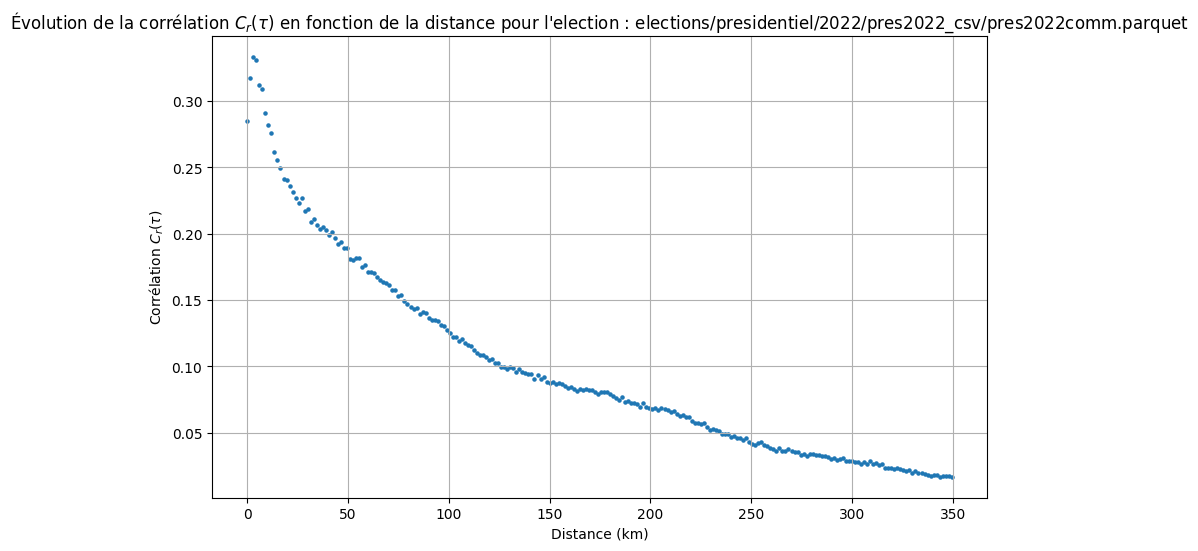

  8%|▊         | 1/12 [06:14<1:08:38, 374.44s/it]

Fetching election data for election elections presidentiel 1981
Creating 200 size bins and computing tau_mean



Processing keys in tau_distributions: 100%|██████████| 12/12 [00:00<00:00, 248.62it/s]


Adding tau to the dataframe
Adding tau mean to the dataframe


/usr/lib/python3.10/functools.py:889: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  return dispatch(args[0].__class__)(*args, **kw)


Convert to Pandas
Compute correlations


<ipython-input-24-7ae649230c26>:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_by_bin = df_pandas.groupby("distance_bin").apply(


Computation dumped at correlation_by_binelections presidentiel 1981.pkl


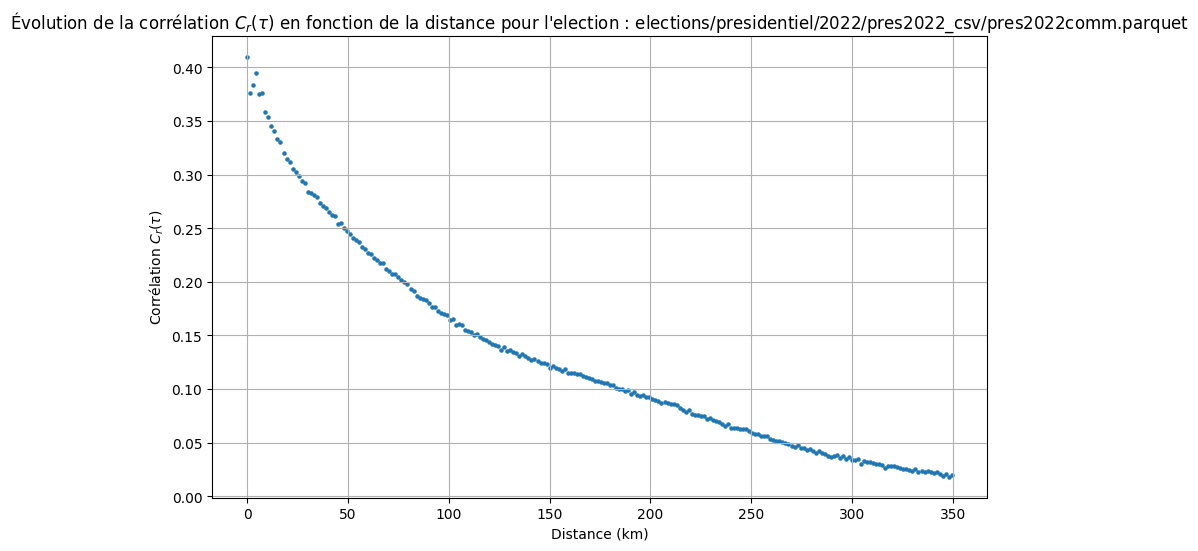

 17%|█▋        | 2/12 [12:29<1:02:29, 374.93s/it]

Fetching election data for election elections presidentiel 2022
Creating 200 size bins and computing tau_mean



Processing keys in tau_distributions: 100%|██████████| 12/12 [00:00<00:00, 244.27it/s]


Adding tau to the dataframe
Adding tau mean to the dataframe


/usr/lib/python3.10/functools.py:889: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  return dispatch(args[0].__class__)(*args, **kw)


Convert to Pandas
Compute correlations


<ipython-input-24-7ae649230c26>:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_by_bin = df_pandas.groupby("distance_bin").apply(


Computation dumped at correlation_by_binelections presidentiel 2022.pkl


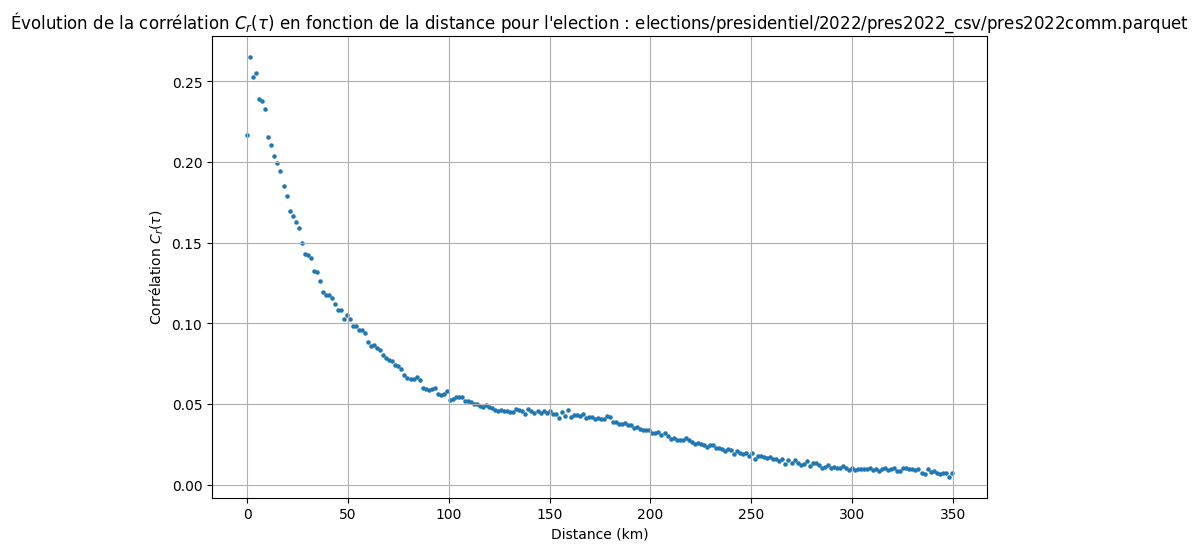

 25%|██▌       | 3/12 [19:17<58:28, 389.88s/it]  

Fetching election data for election elections presidentiel 2012
Creating 200 size bins and computing tau_mean



Processing keys in tau_distributions: 100%|██████████| 12/12 [00:00<00:00, 209.80it/s]


Adding tau to the dataframe
Adding tau mean to the dataframe


/usr/lib/python3.10/functools.py:889: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  return dispatch(args[0].__class__)(*args, **kw)


In [ ]:
for election in tqdm(elections):
    compute_spatial_correlation_for_election(selected_columns_df, election, 200, centroids, communes_code_df, distance_bins, distance_bins_width, df_)